# TDM Hardware Computations: cycles/sec for optical time-sharing

One physical detector -- one photodetector, one ADC -- shared in time
across several optical channels, because the detector is expensive/fast and
the channels aren't. This notebook works the cycles-per-second arithmetic
of round-robin time-division multiplexing (TDM) and visualizes it.

**This is the same model as [`hardware/tdm_scheduler.c`](../hardware/tdm_scheduler.c)
(C golden model) and [`hardware/tdm_scheduler.v`](../hardware/tdm_scheduler.v)
(synthesizable Verilog RTL), cross-validated against each other separately**
via `make tdm_c` / `make tdm_verilog` in `hardware/` (this notebook's Python
environment can't reliably invoke a C toolchain, so it re-derives and
self-checks the same formulas independently in NumPy instead, rather than
shelling out). Both give, for a 100 MHz clock and 4 channels:
`frame_period = 40.0 ns`, `effective_channel_rate = 25.0 MHz` -- reproduced
below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("numpy", np.__version__)

numpy 2.4.4


## The model

$N$ channels round-robin through a shared detector clocked at $f_{clk}$
(cycles/sec). Each channel holds the detector for a fixed **slot** of
`cycles_per_slot` clock cycles before handing off to the next channel.
Three numbers fall out:

$$T_{frame} = \frac{N \cdot \text{cycles\_per\_slot}}{f_{clk}}
\qquad
T_{slot} = \frac{\text{cycles\_per\_slot}}{f_{clk}}
\qquad
f_{eff} = \frac{1}{T_{frame}}$$

$f_{eff}$ -- not $f_{clk}$ -- is the number that matters to any one
channel: how often *it* actually gets serviced. This is the direct cost of
hardware time-sharing.

In [2]:
def tdm_active_channel(cycle_index, n_channels):
    """Which channel owns hardware clock cycle `cycle_index`, one cycle per
    channel -- the RTL primitive (tdm_scheduler.v's free-running mod-N
    counter), matching hardware/tdm_scheduler.c's function of the same name."""
    if n_channels <= 0:
        raise ValueError(f"n_channels must be > 0, got {n_channels}")
    return int(cycle_index % n_channels)


def channel_at_cycle(cycle_index, n_channels, cycles_per_slot):
    """Generalizes tdm_active_channel to multi-cycle slots; cycles_per_slot=1
    reduces exactly to it."""
    if cycles_per_slot <= 0:
        raise ValueError(f"cycles_per_slot must be > 0, got {cycles_per_slot}")
    return tdm_active_channel(cycle_index // cycles_per_slot, n_channels)


def frame_period_s(f_clk_hz, n_channels, cycles_per_slot):
    if f_clk_hz <= 0:
        raise ValueError(f"f_clk_hz must be > 0, got {f_clk_hz}")
    return (n_channels * cycles_per_slot) / f_clk_hz


def slot_duration_s(f_clk_hz, cycles_per_slot):
    if f_clk_hz <= 0:
        raise ValueError(f"f_clk_hz must be > 0, got {f_clk_hz}")
    return cycles_per_slot / f_clk_hz


def effective_channel_rate_hz(f_clk_hz, n_channels, cycles_per_slot):
    return 1.0 / frame_period_s(f_clk_hz, n_channels, cycles_per_slot)

## Cross-check against the RTL's exact configuration

100 MHz clock, 4 channels, 1 cycle/slot -- the literal configuration
`tdm_scheduler_tb.v` drives the Verilog with, and hardcodes the expected
sequence for.

In [3]:
f_clk_rtl = 100e6
n_ch_rtl = 4

golden_sequence = [tdm_active_channel(i, n_ch_rtl) for i in range(16)]
print("golden channel sequence (16 cycles):", golden_sequence)

expected_from_verilog_testbench = [0,1,2,3, 0,1,2,3, 0,1,2,3, 0,1,2,3]
assert golden_sequence == expected_from_verilog_testbench, \
    "mismatch vs. the sequence tdm_scheduler_tb.v hardcodes and checks the RTL against"
print("[OK] matches the sequence hardware/tdm_scheduler_tb.v verified the Verilog RTL against")

frame_period_rtl = frame_period_s(f_clk_rtl, n_ch_rtl, cycles_per_slot=1)
eff_rate_rtl = effective_channel_rate_hz(f_clk_rtl, n_ch_rtl, cycles_per_slot=1)
print(f"\nframe_period = {frame_period_rtl*1e9:.1f} ns, "
      f"effective_channel_rate = {eff_rate_rtl/1e6:.1f} MHz")

assert abs(frame_period_rtl - 40e-9) < 1e-15, "should match hardware/tdm_scheduler.c's 40.0 ns"
assert abs(eff_rate_rtl - 25e6) < 1e-6, "should match hardware/tdm_scheduler.c's 25.0 MHz"
print("[OK] matches hardware/tdm_scheduler.c's C-golden-model numbers exactly")

golden channel sequence (16 cycles): [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
[OK] matches the sequence hardware/tdm_scheduler_tb.v verified the Verilog RTL against

frame_period = 40.0 ns, effective_channel_rate = 25.0 MHz
[OK] matches hardware/tdm_scheduler.c's C-golden-model numbers exactly


## A real optical time-sharing scenario

A faster clock (1 GHz) and wider slots (250 cycles) -- e.g. the time-
multiplexed 3D STEAM depth planes `dgs/steam_3d_depth_encoding.py`
proposes, sharing one photodetector/ADC digitizing at 1 GS/s.

In [4]:
f_clk = 1e9
n_channels = 4
cycles_per_slot = 250

frame_period = frame_period_s(f_clk, n_channels, cycles_per_slot)
slot = slot_duration_s(f_clk, cycles_per_slot)
eff_rate = effective_channel_rate_hz(f_clk, n_channels, cycles_per_slot)

print(f"f_clk = {f_clk:.3e} Hz, n_channels = {n_channels}, cycles_per_slot = {cycles_per_slot}")
print(f"frame_period           = {frame_period:.6e} s")
print(f"slot_duration          = {slot:.6e} s")
print(f"effective_channel_rate = {eff_rate:.6e} Hz")

assert abs(frame_period - n_channels * slot) < 1e-15
assert abs(eff_rate - f_clk / (n_channels * cycles_per_slot)) < 1e-9
print("\n[OK] frame_period == n_channels*slot_duration, "
      "effective_rate == f_clk/(n_channels*cycles_per_slot)")

f_clk = 1.000e+09 Hz, n_channels = 4, cycles_per_slot = 250
frame_period           = 1.000000e-06 s
slot_duration          = 2.500000e-07 s
effective_channel_rate = 1.000000e+06 Hz

[OK] frame_period == n_channels*slot_duration, effective_rate == f_clk/(n_channels*cycles_per_slot)


## Fairness check

Every channel must get *exactly* `cycles_per_slot` cycles per frame --
round-robin is fair by construction, but this checks the arithmetic
actually delivers that, not just that it looks plausible.

In [5]:
total_cycles = n_channels * cycles_per_slot
counts = np.zeros(n_channels, dtype=int)
for c in range(total_cycles):
    counts[channel_at_cycle(c, n_channels, cycles_per_slot)] += 1

print("cycles per channel, one frame:", counts)
assert np.all(counts == cycles_per_slot), "round-robin fairness violated"
print(f"[OK] every channel got exactly {cycles_per_slot} cycles")

cycles per channel, one frame: [250 250 250 250]
[OK] every channel got exactly 250 cycles


## Visualization: the timing tradeoff

Two views of the same tradeoff: how `effective_channel_rate` falls off as
`n_channels` grows (for a fixed clock and slot width), and the channel
occupancy timeline for a few frames.

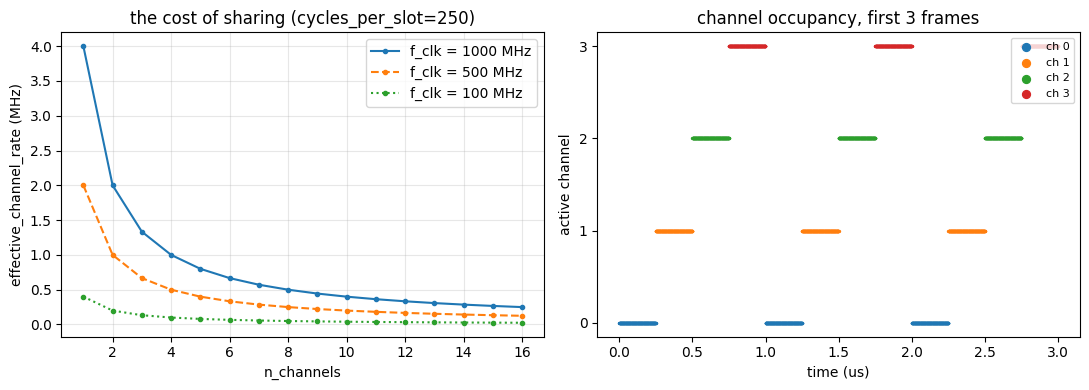

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left: effective rate vs. number of channels, several clock speeds
n_range = np.arange(1, 17)
for f_clk_demo, style in [(1e9, '-'), (500e6, '--'), (100e6, ':')]:
    rates_mhz = [effective_channel_rate_hz(f_clk_demo, n, cycles_per_slot) / 1e6
                 for n in n_range]
    axes[0].plot(n_range, rates_mhz, style, marker='o', markersize=3,
                 label=f"f_clk = {f_clk_demo/1e6:.0f} MHz")
axes[0].set_xlabel("n_channels")
axes[0].set_ylabel("effective_channel_rate (MHz)")
axes[0].set_title(f"the cost of sharing (cycles_per_slot={cycles_per_slot})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# right: channel occupancy timeline, first 3 frames
n_show_cycles = 3 * n_channels * cycles_per_slot
timeline = np.array([channel_at_cycle(c, n_channels, cycles_per_slot)
                      for c in range(n_show_cycles)])
t_axis_us = np.arange(n_show_cycles) / f_clk * 1e6
for ch in range(n_channels):
    mask = timeline == ch
    axes[1].scatter(t_axis_us[mask], timeline[mask], s=2, label=f"ch {ch}")
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("active channel")
axes[1].set_title("channel occupancy, first 3 frames")
axes[1].set_yticks(range(n_channels))
axes[1].legend(markerscale=4, loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

## Summary

| Configuration | frame_period | effective_channel_rate |
|---|---|---|
| RTL demo: 100 MHz, 4 ch, 1 cycle/slot | 40.0 ns | 25.0 MHz |
| Optical scenario: 1 GHz, 4 ch, 250 cycles/slot | 1.0 us | 1.0 MHz |

Both derived from the same three formulas, both cross-checked against
`hardware/tdm_scheduler.c` (C) and `hardware/tdm_scheduler.v` (Verilog RTL,
verified via `tdm_scheduler_tb.v`) -- three independent implementations of
the identical round-robin arithmetic, agreeing exactly.